НИРС — Анализ чувствительности результатов событийного анализа

**Тема:** Анализ чувствительности результатов событийного анализа к выбору параметров исследования  
**Период:** 2015–2019  
**Выборка:** 11 компаний, 110 дивидендных событий  
**Параметры:** 3 модели × 3 окна события × 3 оценочных окна = 27 комбинаций

## 1. Загрузка данных

In [4]:
import os
import sys

sys.path.insert(0, os.path.join(os.path.dirname(''), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from core.event_study import EventStudy
from core.dividend_data_provider import load_dividends
from core.market_data_provider import load_risk_free_rate, load_market_index
from core.stock_data_provider import get_log_returns

TICKERS = ['CHMF', 'FEES', 'GMKN', 'LKOH', 'MGNT',
           'MOEX', 'MTSS', 'RTKM', 'SBER', 'TATN', 'UPRO']

START = '2013-01-01'  # с запасом для max оценочного окна 300 дней
END = '2019-12-31'

In [ ]:
events = load_dividends()
prices = {t: get_log_returns(t, start_date=START, end_date=END) for t in TICKERS}
market = load_market_index(start_date=START, end_date=END)
rf = load_risk_free_rate()

studies = {t: EventStudy(stock=prices[t]) for t in TICKERS}

print(f'Событий загружено:  {len(events)}')
print(f'Тикеров загружено:  {len(prices)}')
print(f'IMOEX строк:        {len(market)}')
print(f'RUONIA строк:       {len(rf)}')
print()
print('Котировки по тикерам:')
for t, s in sorted(prices.items()):
    print(f'  {t}: {len(s)} торговых дней  ({s.index.min().date()} – {s.index.max().date()})')

## 2. Промежуточный результат — одна компания, одна конфигурация

In [6]:
# Тестовая конфигурация
model = 'market_model'
ew = (-10, 10)
esw = 200

# Фильтруем события только по LKOH
lkoh_events = [e for e in events if e.ticker == 'LKOH']
study_lkoh = studies['LKOH']

cars = []
for ev in lkoh_events:
    result = study_lkoh.analyze(
        event_date=ev.event_date,
        model=model,
        event_window=ew,
        estimation_window=esw,
        market=market,
    )
    if result is not None:
        cars.append(result.car)

if len(cars) >= 2:
    arr = np.array(cars)
    t_val, p_val = stats.ttest_1samp(arr, popmean=0.0)
    print(f'LKOH: mean_CAR={arr.mean():.4f}  t={t_val:.3f}  '
          f'p={p_val:.3f}  significant={p_val < 0.05}  n={len(cars)}')

LKOH: mean_CAR=-0.0041  t=-0.260  p=0.800  significant=False  n=10


## 3. Полное исследование — 27 комбинаций

### Описание колонок результирующей таблицы

Каждая строка соответствует одной из 27 комбинаций параметров (3 модели × 3 событийных окна × 3 оценочных окна).

**Компанейский уровень** (агрегирование по 11 компаниям → t-тест по 11 значениям):

| Колонка | Описание |
|---|---|
| `model` | Модель нормальной доходности: `mean_adjusted` — постоянная средняя; `market_model` — рыночная модель (OLS: r = α + β·r_m); `capm` — CAPM (r = rf + β·(r_m − rf), alpha=0) |
| `event_window` | Событийное окно: диапазон дней относительно даты события (t = 0) |
| `estimation_window` | Длина оценочного окна (торговые дни), предшествующего событийному: 100, 200 или 300 дней |
| `mean_car` | Средняя CAR по 11 компаниям (equal-weighted) |
| `std_car` | Стандартное отклонение mean_CAR между компаниями |
| `t_stat` | t-статистика одновыборочного t-теста по 11 компаниям (H₀: mean_CAR = 0) |
| `p_value` | p-значение двустороннего t-теста (компанейский уровень) |
| `significant` | Значимость при α = 5% (компанейский уровень) |

**Событийный уровень** (t-тест напрямую по ~110 событиям — более высокая мощность):

| Колонка | Описание |
|---|---|
| `t_stat_events` | t-статистика по всем ~110 событиям |
| `p_value_events` | p-значение двустороннего t-теста (событийный уровень) |
| `significant_events` | Значимость при α = 5% (событийный уровень) |
| `n_events_total` | Фактическое число событий, вошедших в расчёт |

In [7]:
COMPANY_NAMES = {
    'CHMF': 'Северсталь',
    'FEES': 'ФСК ЕЭС',
    'GMKN': 'ГМК Норильский никель',
    'LKOH': 'Лукойл',
    'MGNT': 'Магнит',
    'MOEX': 'Московская биржа',
    'MTSS': 'МТС',
    'RTKM': 'Ростелеком',
    'SBER': 'Сбербанк',
    'TATN': 'Татнефть',
    'UPRO': 'Юнипро',
}

MODELS = ['mean_adjusted', 'market_model', 'capm']
EVENT_WINDOWS = [(-3, 3), (-10, 10), (-20, 20)]
ESTIMATION_WINDOWS = [100, 200, 300]

events_by_ticker = {}
for ev in events:
    events_by_ticker.setdefault(ev.ticker, []).append(ev)

# --- Перебор 27 конфигураций ---
all_rows = []  # все CARs по событиям (для агрегации на обоих уровнях)

for model_name in MODELS:
    extra = {}
    if model_name in ('market_model', 'capm'):
        extra['market'] = market
    if model_name == 'capm':
        extra['rf'] = rf

    for ew in EVENT_WINDOWS:
        for esw in ESTIMATION_WINDOWS:
            for ev in events:
                result = studies[ev.ticker].analyze(
                    event_date=ev.event_date,
                    model=model_name,
                    event_window=ew,
                    estimation_window=esw,
                    **extra,
                )
                if result is None:
                    continue
                all_rows.append({
                    'model': model_name,
                    'event_window': f"[{ew[0]}, +{ew[1]}]",
                    'estimation_window': esw,
                    'ticker': ev.ticker,
                    'company': COMPANY_NAMES.get(ev.ticker, ev.ticker),
                    'event_date': ev.event_date,
                    'car': result.car,
                })

cars_df = pd.DataFrame(all_rows)
print(f'Всего расчётов: {len(cars_df)}')

# --- Промежуточный уровень: по компаниям ---
company_df = (
    cars_df
    .groupby(['model', 'event_window', 'estimation_window', 'ticker', 'company'])
    .agg(
        n_events=('car', 'count'),
        mean_car=('car', 'mean'),
        std_car=('car', 'std'),
    )
    .reset_index()
)

# t-тест и значимость для каждой компании
def _ttest_row(row):
    group = cars_df[
        (cars_df['model'] == row['model']) &
        (cars_df['event_window'] == row['event_window']) &
        (cars_df['estimation_window'] == row['estimation_window']) &
        (cars_df['ticker'] == row['ticker'])
    ]['car'].values
    if len(group) < 2:
        return pd.Series({'t_stat': 0.0, 'p_value': 1.0, 'significant': False})
    t_val, p_val = stats.ttest_1samp(group, popmean=0.0)
    return pd.Series({'t_stat': round(float(t_val), 4), 'p_value': round(float(p_val), 4), 'significant': p_val < 0.05})

company_df[['t_stat', 'p_value', 'significant']] = company_df.apply(_ttest_row, axis=1)
company_df['mean_car'] = company_df['mean_car'].round(6)
company_df['std_car'] = company_df['std_car'].round(6)

groups_by_config = company_df.groupby(['model', 'event_window', 'estimation_window'])
print(len(groups_by_config))
for (mdl, ew, esw), group in groups_by_config:
    print(f'\n{mdl} | окно {ew} | оценочное {esw} дней. Значимо={group["significant"].sum()}')
    display(group[['ticker', 'company', 'n_events', 'mean_car', 't_stat', 'p_value', 'significant']].reset_index(drop=True))

Всего расчётов: 2970
27

capm | окно [-10, +10] | оценочное 100 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,CHMF,Северсталь,20,0.022104,1.5233,0.1441,False
1,FEES,ФСК ЕЭС,7,0.034982,1.3765,0.2178,False
2,GMKN,ГМК Норильский никель,12,0.001009,0.0479,0.9627,False
3,LKOH,Лукойл,10,0.001063,0.0763,0.9409,False
4,MGNT,Магнит,12,-0.008267,-0.4211,0.6818,False
5,MOEX,Московская биржа,6,-0.016357,-0.4774,0.6532,False
6,MTSS,МТС,11,-0.001007,-0.1097,0.9149,False
7,RTKM,Ростелеком,6,-0.003214,-0.9814,0.3715,False
8,SBER,Сбербанк,5,0.025281,0.5574,0.6070,False
9,TATN,Татнефть,10,0.033557,1.1370,0.2849,False



capm | окно [-10, +10] | оценочное 200 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,CHMF,Северсталь,20,0.021785,1.5081,0.1480,False
1,FEES,ФСК ЕЭС,7,0.026828,0.9563,0.3759,False
2,GMKN,ГМК Норильский никель,12,-0.000994,-0.0498,0.9612,False
3,LKOH,Лукойл,10,0.001319,0.0946,0.9267,False
4,MGNT,Магнит,12,-0.007678,-0.3899,0.7041,False
5,MOEX,Московская биржа,6,-0.013537,-0.4261,0.6878,False
6,MTSS,МТС,11,-0.001407,-0.1561,0.8791,False
7,RTKM,Ростелеком,6,-0.002655,-0.7619,0.4805,False
8,SBER,Сбербанк,5,0.025553,0.5640,0.6029,False
9,TATN,Татнефть,10,0.032245,1.0896,0.3042,False



capm | окно [-10, +10] | оценочное 300 дней. Значимо=0


...

,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,CHMF,Северсталь,20,0.011994,1.3804,0.1835,False
1,FEES,ФСК ЕЭС,7,-0.021258,-0.8065,0.4507,False
2,GMKN,ГМК Норильский никель,12,0.002872,0.1589,0.8767,False
3,LKOH,Лукойл,10,0.009776,0.8276,0.4293,False
4,MGNT,Магнит,12,0.013282,1.1141,0.2890,False
5,MOEX,Московская биржа,6,-0.019361,-0.7460,0.4892,False
6,MTSS,МТС,11,0.004667,0.3105,0.7625,False
7,RTKM,Ростелеком,6,-0.001602,-0.2022,0.8477,False
8,SBER,Сбербанк,5,0.034098,1.1786,0.3039,False
9,TATN,Татнефть,10,0.025280,1.3820,0.2003,False



mean_adjusted | окно [-3, +3] | оценочное 200 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,CHMF,Северсталь,20,0.008281,1.0479,0.3078,False
1,FEES,ФСК ЕЭС,7,-0.018972,-0.6157,0.5607,False
2,GMKN,ГМК Норильский никель,12,0.000322,0.0188,0.9853,False
3,LKOH,Лукойл,10,0.009769,0.8580,0.4131,False
4,MGNT,Магнит,12,0.013824,1.1822,0.2620,False
5,MOEX,Московская биржа,6,-0.015984,-0.6221,0.5612,False
6,MTSS,МТС,11,0.004730,0.3163,0.7583,False
7,RTKM,Ростелеком,6,-0.004145,-0.4855,0.6478,False
8,SBER,Сбербанк,5,0.030858,1.1950,0.2981,False
9,TATN,Татнефть,10,0.024988,1.3744,0.2026,False



mean_adjusted | окно [-3, +3] | оценочное 300 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,CHMF,Северсталь,20,0.009621,1.2309,0.2334,False
1,FEES,ФСК ЕЭС,7,-0.020678,-0.6033,0.5684,False
2,GMKN,ГМК Норильский никель,12,0.000675,0.0395,0.9692,False
3,LKOH,Лукойл,10,0.010567,0.9547,0.3647,False
4,MGNT,Магнит,12,0.012689,1.1251,0.2845,False
5,MOEX,Московская биржа,6,-0.016459,-0.6635,0.5364,False
6,MTSS,МТС,11,0.005759,0.3989,0.6984,False
7,RTKM,Ростелеком,6,-0.001876,-0.2339,0.8244,False
8,SBER,Сбербанк,5,0.032934,1.3600,0.2454,False
9,TATN,Татнефть,10,0.024933,1.3767,0.2019,False


In [8]:
# --- Агрегированный уровень: 27 конфигураций ---
def _ttest_1samp(arr):
    if len(arr) < 2:
        return 0.0, 1.0
    result = stats.ttest_1samp(arr, popmean=0.0)
    return float(result.statistic), float(result.pvalue)

agg_rows = []
for (mdl, ew, esw), group in cars_df.groupby(['model', 'event_window', 'estimation_window']):
    # Компанейский уровень
    company_means = group.groupby('ticker')['car'].mean()
    company_means = company_means[group.groupby('ticker')['car'].count() >= 2]
    if len(company_means) == 0:
        continue
    cm = company_means.values
    t_comp, p_comp = _ttest_1samp(cm)

    # Событийный уровень
    ev_arr = group['car'].values
    t_ev, p_ev = _ttest_1samp(ev_arr)

    agg_rows.append({
        'model': mdl, 'event_window': ew, 'estimation_window': esw,
        'mean_car': round(float(cm.mean()), 6),
        'std_car': round(float(cm.std(ddof=1)), 6) if len(cm) > 1 else 0.0,
        't_stat': round(t_comp, 4), 'p_value': round(p_comp, 4),
        'significant': p_comp < 0.05,
        't_stat_events': round(t_ev, 4), 'p_value_events': round(p_ev, 4),
        'significant_events': p_ev < 0.05,
        'n_events_total': len(ev_arr),
    })

results_df = pd.DataFrame(agg_rows)
print('\nАгрегированный уровень (по конфигурациям):')
results_df


Агрегированный уровень (по конфигурациям):


,model,event_window,estimation_window,mean_car,std_car,t_stat,p_value,significant,t_stat_events,p_value_events,significant_events,n_events_total
0,capm,"[-10, +10]",100,0.008197,0.017575,1.5468,0.1529,False,1.4326,0.1548,False,110
1,capm,"[-10, +10]",200,0.007282,0.015998,1.5097,0.1621,False,1.2998,0.1964,False,110
2,capm,"[-10, +10]",300,0.006405,0.014620,1.4531,0.1768,False,1.1443,0.2550,False,110
3,capm,"[-20, +20]",100,0.015764,0.040459,1.2923,0.2253,False,1.2221,0.2243,False,110
4,capm,"[-20, +20]",200,0.014624,0.038755,1.2515,0.2392,False,1.1117,0.2687,False,110
5,capm,"[-20, +20]",300,0.012845,0.036826,1.1568,0.2742,False,0.9379,0.3503,False,110
6,capm,"[-3, +3]",100,0.007453,0.010240,2.4140,0.0364,True,2.3094,0.0228,True,110
7,capm,"[-3, +3]",200,0.006850,0.011062,2.0538,0.0671,False,2.1137,0.0368,True,110
8,capm,"[-3, +3]",300,0.006655,0.011321,1.9496,0.0798,False,2.0373,0.0440,True,110
9,market_model,"[-10, +10]",100,0.007692,0.010964,2.3266,0.0423,True,1.3510,0.1795,False,110


## 4. Сводная таблица: значимые комбинации

In [9]:
cols_show = ['model', 'event_window', 'estimation_window',
             'mean_car', 't_stat', 'p_value', 'significant',
             't_stat_events', 'p_value_events', 'significant_events']

sig_comp   = results_df[results_df['significant']]
sig_events = results_df[results_df['significant_events']]

print(f'Значимых комбинаций (компанейский уровень, n=11, p < 0.05): '
      f'{len(sig_comp)} из {len(results_df)}')
display(sig_comp[cols_show].reset_index(drop=True))

print(f'\nЗначимых комбинаций (событийный уровень, n≈110, p < 0.05): '
      f'{len(sig_events)} из {len(results_df)}')
display(sig_events[cols_show].reset_index(drop=True))

Значимых комбинаций (компанейский уровень, n=11, p < 0.05): 5 из 27


,model,event_window,estimation_window,mean_car,t_stat,p_value,significant,t_stat_events,p_value_events,significant_events
0,capm,"[-3, +3]",100,0.007453,2.4140,0.0364,True,2.3094,0.0228,True
1,market_model,"[-10, +10]",100,0.007692,2.3266,0.0423,True,1.3510,0.1795,False
2,market_model,"[-10, +10]",200,0.007827,2.5236,0.0302,True,1.2859,0.2012,False
3,market_model,"[-3, +3]",100,0.006913,2.6023,0.0264,True,2.2306,0.0278,True
4,market_model,"[-3, +3]",200,0.006693,2.5897,0.0270,True,2.0722,0.0406,True



Значимых комбинаций (событийный уровень, n≈110, p < 0.05): 5 из 27


,model,event_window,estimation_window,mean_car,t_stat,p_value,significant,t_stat_events,p_value_events,significant_events
0,capm,"[-3, +3]",100,0.007453,2.4140,0.0364,True,2.3094,0.0228,True
1,capm,"[-3, +3]",200,0.006850,2.0538,0.0671,False,2.1137,0.0368,True
2,capm,"[-3, +3]",300,0.006655,1.9496,0.0798,False,2.0373,0.0440,True
3,market_model,"[-3, +3]",100,0.006913,2.6023,0.0264,True,2.2306,0.0278,True
4,market_model,"[-3, +3]",200,0.006693,2.5897,0.0270,True,2.0722,0.0406,True


## 5. График средних CAR по окну события (одна конфигурация)

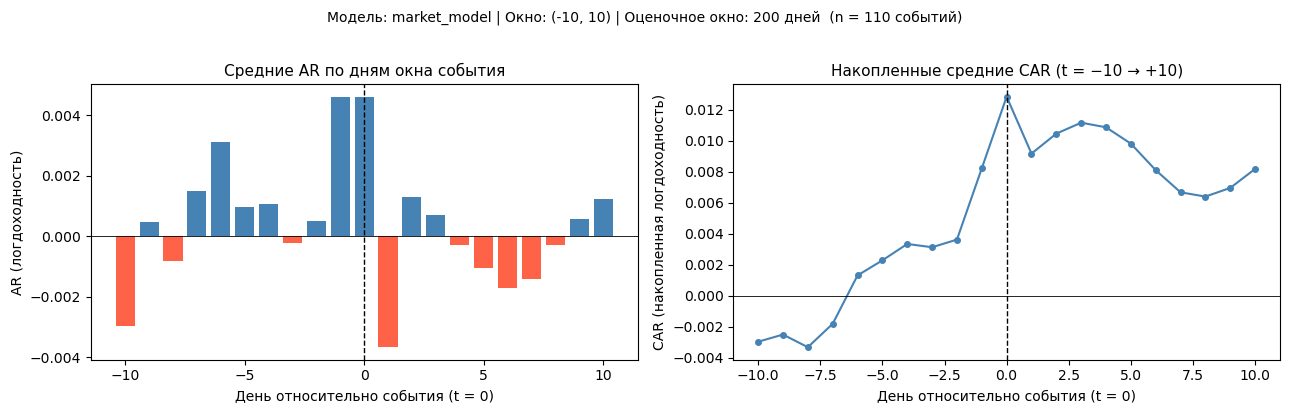

In [10]:
plot_model = 'market_model'
plot_ew = (-10, 10)
plot_esw = 200

# Собираем AR по всем событиям
all_ar: list[list[float]] = []
for ev in events:
    res = studies[ev.ticker].analyze(
        event_date=ev.event_date,
        model=plot_model,
        event_window=plot_ew,
        estimation_window=plot_esw,
        market=market,
    )
    if res is not None and len(res.ar) == 21:  # ровно 21 день [-10..+10]
        all_ar.append(res.ar)

if all_ar:
    ar_matrix = np.array(all_ar)       # shape (n_events, 21)
    mean_ar   = ar_matrix.mean(axis=0)
    cum_ar    = np.cumsum(mean_ar)
    days      = list(range(-10, 11))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(days, mean_ar, color=['tomato' if x < 0 else 'steelblue' for x in mean_ar])
    axes[0].axvline(0, color='black', lw=1, linestyle='--')
    axes[0].axhline(0, color='black', lw=0.6)
    axes[0].set_title('Средние AR по дням окна события', fontsize=11)
    axes[0].set_xlabel('День относительно события (t = 0)')
    axes[0].set_ylabel('AR (логдоходность)')

    axes[1].plot(days, cum_ar, marker='o', markersize=4, color='steelblue')
    axes[1].axvline(0, color='black', lw=1, linestyle='--')
    axes[1].axhline(0, color='black', lw=0.6)
    axes[1].set_title('Накопленные средние CAR (t = −10 → +10)', fontsize=11)
    axes[1].set_xlabel('День относительно события (t = 0)')
    axes[1].set_ylabel('CAR (накопленная логдоходность)')

    plt.suptitle(f'Модель: {plot_model} | Окно: {plot_ew} | '
                 f'Оценочное окно: {plot_esw} дней  '
                 f'(n = {len(all_ar)} событий)', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig('../docs/car_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('Недостаточно данных для построения графика.')

## 5b. Сравнение трёх моделей: средние CAR по окну события

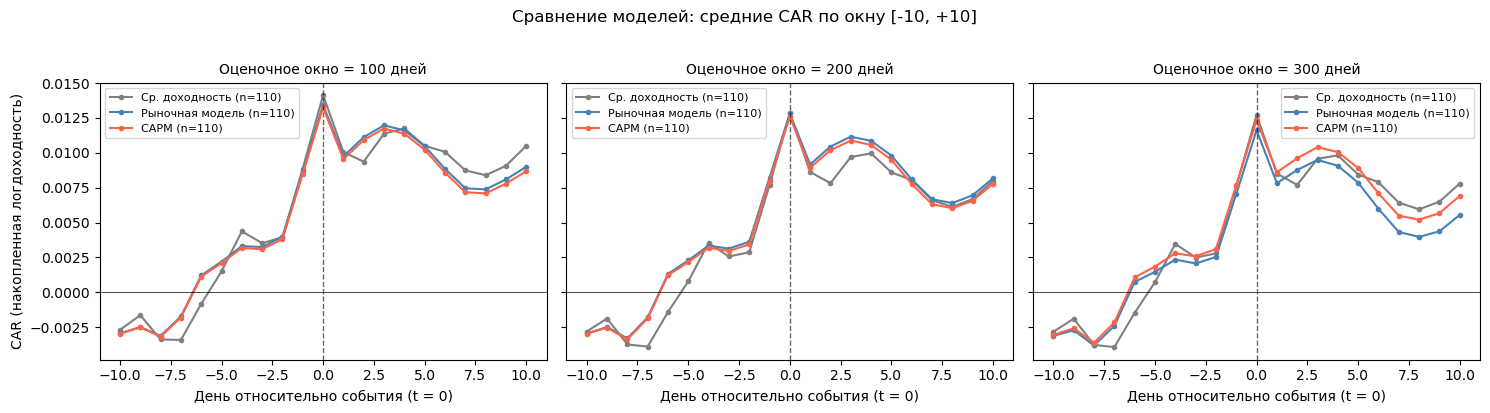

In [11]:
models_to_plot   = ['mean_adjusted', 'market_model', 'capm']
model_labels     = {
    'mean_adjusted': 'Ср. доходность',
    'market_model':  'Рыночная модель',
    'capm':          'CAPM',
}
colors           = {'mean_adjusted': 'gray', 'market_model': 'steelblue', 'capm': 'tomato'}
estimation_wins  = [100, 200, 300]
comp_event_win   = (-10, 10)   # фиксируем событийное окно для сравнения
n_days_expected  = comp_event_win[1] - comp_event_win[0] + 1
days_comp        = list(range(comp_event_win[0], comp_event_win[1] + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, esw in zip(axes, estimation_wins):
    for mname in models_to_plot:
        extra = {}
        if mname in ('market_model', 'capm'):
            extra['market'] = market
        if mname == 'capm':
            extra['rf'] = rf

        ar_list = []
        for ev in events:
            res = studies[ev.ticker].analyze(
                event_date=ev.event_date,
                model=mname,
                event_window=comp_event_win,
                estimation_window=esw,
                **extra,
            )
            if res is not None and len(res.ar) == n_days_expected:
                ar_list.append(res.ar)
        if not ar_list:
            continue
        cum_ar = np.cumsum(np.array(ar_list).mean(axis=0))
        ax.plot(days_comp, cum_ar,
                label=f'{model_labels[mname]} (n={len(ar_list)})',
                color=colors[mname], marker='o', markersize=3, linewidth=1.5)

    ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'Оценочное окно = {esw} дней', fontsize=10)
    ax.set_xlabel('День относительно события (t = 0)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('CAR (накопленная логдоходность)')
plt.suptitle('Сравнение моделей: средние CAR по окну [-10, +10]', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../docs/car_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Сравнение моделей (heatmap t-статистик)

C:\Users\Ruslan\AppData\Local\Temp\ipykernel_10224\1657222261.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


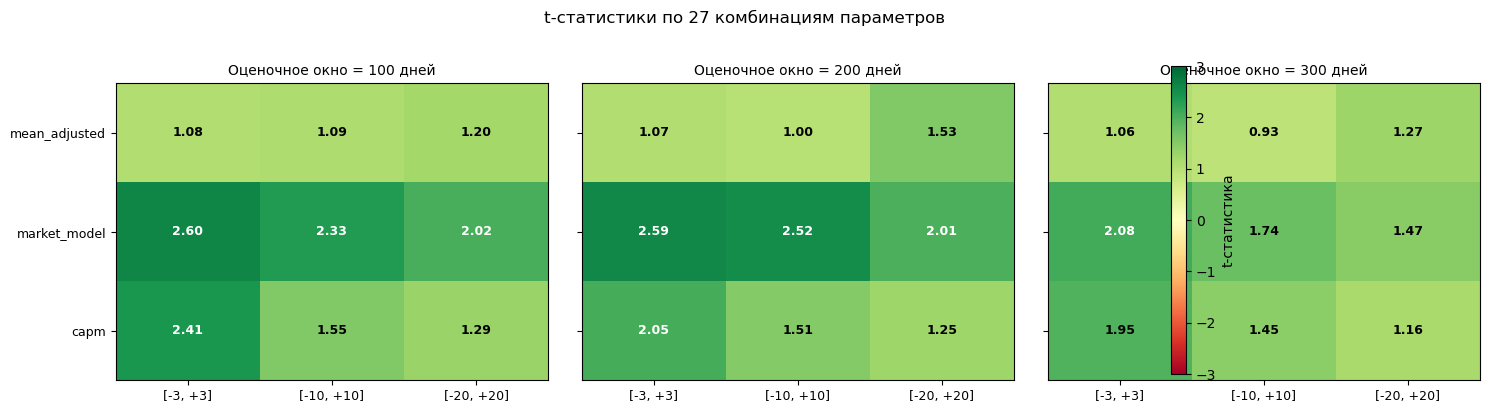

In [12]:
models = ['mean_adjusted', 'market_model', 'capm']
windows = ['[-3, +3]', '[-10, +10]', '[-20, +20]']
est_windows = [100, 200, 300]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, esw in zip(axes, est_windows):
    sub = results_df[results_df['estimation_window'] == esw]
    matrix = []
    for m in models:
        row = []
        for ew in windows:
            val = sub[(sub['model'] == m) & (sub['event_window'] == ew)]['t_stat']
            row.append(float(val.iloc[0]) if len(val) > 0 else 0.0)
        matrix.append(row)

    mat = np.array(matrix)
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-3, vmax=3, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_xticklabels(windows, fontsize=9)
    ax.set_yticks(range(3))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_title(f'Оценочное окно = {esw} дней', fontsize=10)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if abs(mat[i, j]) > 2 else 'black')

plt.colorbar(im, ax=axes, label='t-статистика')
plt.suptitle('t-статистики по 27 комбинациям параметров', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../docs/heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Экспорт результатов

In [13]:
results_df

,model,event_window,estimation_window,mean_car,std_car,t_stat,p_value,significant,t_stat_events,p_value_events,significant_events,n_events_total
0,capm,"[-10, +10]",100,0.008197,0.017575,1.5468,0.1529,False,1.4326,0.1548,False,110
1,capm,"[-10, +10]",200,0.007282,0.015998,1.5097,0.1621,False,1.2998,0.1964,False,110
2,capm,"[-10, +10]",300,0.006405,0.014620,1.4531,0.1768,False,1.1443,0.2550,False,110
3,capm,"[-20, +20]",100,0.015764,0.040459,1.2923,0.2253,False,1.2221,0.2243,False,110
4,capm,"[-20, +20]",200,0.014624,0.038755,1.2515,0.2392,False,1.1117,0.2687,False,110
5,capm,"[-20, +20]",300,0.012845,0.036826,1.1568,0.2742,False,0.9379,0.3503,False,110
6,capm,"[-3, +3]",100,0.007453,0.010240,2.4140,0.0364,True,2.3094,0.0228,True,110
7,capm,"[-3, +3]",200,0.006850,0.011062,2.0538,0.0671,False,2.1137,0.0368,True,110
8,capm,"[-3, +3]",300,0.006655,0.011321,1.9496,0.0798,False,2.0373,0.0440,True,110
9,market_model,"[-10, +10]",100,0.007692,0.010964,2.3266,0.0423,True,1.3510,0.1795,False,110
